In [1]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# ==========================================
# Global Hyperparameters
# ==========================================
SEED = 0
LR = 0.01
EPOCHS = 100
N_SAMPLES = 10000
X_TRAIN = np.linspace(-np.pi, np.pi, 10)

# Generate shared initial parameters for a fair comparison
np.random.seed(SEED)
SHARED_INIT_THETAS = np.random.uniform(0.1, 1.0, 2)


# =====================================================================
# PART 1: BATCHED MPS (REAL ISOMORPHISM) & STOCHASTIC PSR
# =====================================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
f_dtype = torch.float32

# --- Real-Matrix Isomorphism for Quantum Gates ---
I_mps = torch.eye(4, dtype=f_dtype, device=device)

miX = torch.tensor([
    [ 0.,  0.,  0.,  1.],
    [ 0.,  0.,  1.,  0.],
    [ 0., -1.,  0.,  0.],
    [-1.,  0.,  0.,  0.]
], dtype=f_dtype, device=device)

miY = torch.tensor([
    [ 0., -1.,  0.,  0.],
    [ 1.,  0.,  0.,  0.],
    [ 0.,  0.,  0., -1.],
    [ 0.,  0.,  1.,  0.]
], dtype=f_dtype, device=device)

miZ = torch.tensor([
    [ 0.,  0.,  1.,  0.],
    [ 0.,  0.,  0., -1.],
    [-1.,  0.,  0.,  0.],
    [ 0.,  1.,  0.,  0.]
], dtype=f_dtype, device=device)

def rx_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miX

def ry_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miY

def rz_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_mps + torch.sin(theta/2) * miZ

# 原生 Ansatz: 估算 f(x)
def q_ansatz_L1_batched(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    t0_t = torch.atleast_1d(torch.as_tensor(thetas[0], device=device, dtype=f_dtype))
    t1_t = torch.atleast_1d(torch.as_tensor(thetas[1], device=device, dtype=f_dtype))

    N = max(x_t.numel(), t0_t.numel(), t1_t.numel())

    state = torch.tensor([[1.], [0.], [0.], [0.]], dtype=f_dtype, device=device).expand(N, 4, 1)
    state = ry_batched(x_t) @ state
    state = rz_batched(t1_t) @ state
    state = rx_batched(t0_t) @ state

    prob_0 = state[:, 0, 0]**2 + state[:, 2, 0]**2
    outcomes = torch.where(torch.rand(N, device=device) < prob_0, 1.0, -1.0)
    return outcomes

# 【新增】Average Operator Ansatz: 估算 Af(x)
def q_ansatz_L1_batched_Af(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    # 为 batch 中的每个样本生成随机符号：50% 是 1，50% 是 -1
    signs = torch.where(torch.rand(x_t.shape, device=device) < 0.5, 1.0, -1.0)
    x_flipped = x_t * signs
    # 将翻转后的 x 输入到原始的 ansatz 中
    return q_ansatz_L1_batched(x_flipped, thetas)

# --- 引入 ansatz_func 参数，使得同一个 PSR 函数可以处理 f(x) 和 Af(x) ---
def stochastic_psr_1st_x_mps(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_plus = torch.full((num_samples,), float(x) + s, device=device, dtype=f_dtype)
    x_minus = torch.full((num_samples,), float(x) - s, device=device, dtype=f_dtype)
    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_2nd_x_mps(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([2.0, -2.0], device=device)
    G_minus = torch.tensor([0.0, 0.0], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    x_plus = float(x) + G_plus[idx_plus] * s
    x_minus = float(x) + G_minus[idx_minus] * s

    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def psr_1st_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_batch = torch.full((num_samples,), float(x), device=device, dtype=f_dtype)

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + s
    t_minus[target_idx] = float(thetas[target_idx]) - s

    f_plus_est = ansatz_func(x_batch, t_plus).mean()
    f_minus_est = ansatz_func(x_batch, t_minus).mean()
    return 0.5 * (f_plus_est - f_minus_est).item()

def stochastic_psr_2nd_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[1.0, 1.0], [-1.0, -1.0]], device=device)
    G_minus = torch.tensor([[-1.0, 1.0], [1.0, -1.0]], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_3rd_theta_mps(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[2.0, 1.0], [-2.0, 1.0], [0.0, -1.0], [0.0, -1.0]], device=device)
    G_minus = torch.tensor([[2.0, -1.0], [-2.0, -1.0], [0.0, 1.0], [0.0, 1.0]], device=device)

    idx_plus = torch.randint(0, 4, (num_samples,), device=device)
    idx_minus = torch.randint(0, 4, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

# 原始 f(x) 训练循环
def train_batched_psr():
    print(f"\n--- Starting Batched PSR Training for f(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)
            f_val = q_ansatz_L1_batched(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_mps(x, thetas, N_SAMPLES)
            f_xx_val = stochastic_psr_2nd_x_mps(x, thetas, N_SAMPLES)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_mps(x, thetas, p_idx, N_SAMPLES)
                d_fx_theta = stochastic_psr_2nd_theta_mps(x, thetas, p_idx, N_SAMPLES)
                d_fxx_theta = stochastic_psr_3rd_theta_mps(x, thetas, p_idx, N_SAMPLES)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas

# 【新增】 Af(x) 训练循环
def train_batched_psr_Af():
    print(f"\n--- Starting Batched PSR Training for Af(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)

            # 使用包装过 Af(x) 的 ansatz
            f_val = q_ansatz_L1_batched_Af(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_mps(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
            f_xx_val = stochastic_psr_2nd_x_mps(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fx_theta = stochastic_psr_2nd_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fxx_theta = stochastic_psr_3rd_theta_mps(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas


# =====================================================================
# PART 2: PYTORCH & AUTOMATIC DIFFERENTIATION IMPLEMENTATION (UNCHANGED)
# =====================================================================

I_th = torch.tensor([[1, 0], [0, 1]], dtype=torch.complex128)
X_th = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128)
Y_th = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128)
Z_th = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)

def rx_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * X_th

def ry_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Y_th

def rz_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Z_th

def q_ansatz_L1_torch(x, thetas):
    state = torch.tensor([1, 0], dtype=torch.complex128)
    state = ry_th(x) @ state
    state = rx_th(thetas[0]) @ rz_th(thetas[1]) @ state
    exp_val = torch.vdot(state, Z_th @ state).real
    return exp_val

def train_pytorch_autodiff():
    print("\n--- Starting PyTorch + Autograd Training (CPU Baseline) ---")
    thetas = torch.nn.Parameter(torch.tensor(SHARED_INIT_THETAS, dtype=torch.float64))
    optimizer = optim.SGD([thetas], lr=LR)
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        total_loss = 0.0

        for x_val in X_TRAIN:
            x = torch.tensor([x_val], dtype=torch.float64, requires_grad=True)

            f_val = q_ansatz_L1_torch(x, thetas)
            f_x_val = torch.autograd.grad(f_val, x, create_graph=True)[0]
            f_xx_val = torch.autograd.grad(f_x_val, x, create_graph=True)[0]

            res = f_xx_val + f_x_val + f_val - torch.sin(x)
            loss = 0.5 * (res ** 2)
            total_loss = total_loss + loss

        mean_loss = total_loss / len(X_TRAIN)
        mean_loss.backward()
        optimizer.step()
        loss_history.append(mean_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {mean_loss.item():.6f} | theta_0: {thetas[0].item():.4f}, theta_1: {thetas[1].item():.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas.detach().numpy()


# =====================================================================
# PART 3: EXECUTION AND PLOTTING
# =====================================================================
if __name__ == "__main__":
    print(f"Shared Initial parameters: theta_0 = {SHARED_INIT_THETAS[0]:.4f}, theta_1 = {SHARED_INIT_THETAS[1]:.4f}")
    print("Target parameters for f(x): theta_0 = pi, theta_1 = 0 \n")

    # Run all three models
    loss_np, final_thetas_np = train_batched_psr()
    loss_af, final_thetas_af = train_batched_psr_Af()
    loss_th, final_thetas_th = train_pytorch_autodiff()

    print("\n--- Final Results Comparison ---")

Shared Initial parameters: theta_0 = 0.5939, theta_1 = 0.7437
Target parameters for f(x): theta_0 = pi, theta_1 = 0 


--- Starting Batched PSR Training for f(x) on CPU ---
Epoch 10  | Loss: 0.682456 | theta_0: 1.0211, theta_1: 0.5881
Epoch 20  | Loss: 0.343340 | theta_0: 1.5249, theta_1: 0.3885
Epoch 30  | Loss: 0.134813 | theta_0: 1.9082, theta_1: 0.2248
Epoch 40  | Loss: 0.063440 | theta_0: 2.1378, theta_1: 0.1454
Epoch 50  | Loss: 0.032134 | theta_0: 2.2772, theta_1: 0.1010
Epoch 60  | Loss: 0.015973 | theta_0: 2.3757, theta_1: 0.0766
Epoch 70  | Loss: 0.015410 | theta_0: 2.4510, theta_1: 0.0697
Epoch 80  | Loss: 0.018217 | theta_0: 2.5115, theta_1: 0.0539
Epoch 90  | Loss: 0.012067 | theta_0: 2.5655, theta_1: 0.0408
Epoch 100 | Loss: 0.002882 | theta_0: 2.6033, theta_1: 0.0315
Time taken: 2.10 seconds

--- Starting Batched PSR Training for Af(x) on CPU ---
Epoch 10  | Loss: 0.450540 | theta_0: 1.1115, theta_1: 0.7357
Epoch 20  | Loss: 0.182911 | theta_0: 1.6311, theta_1: 0.7566
Ep

In [12]:
import numpy as np
import torch
import torch.optim as optim
import time

# ==========================================
# Global Hyperparameters
# ==========================================
SEED = 0
LR = 0.1
EPOCHS = 500
N_SAMPLES = 100000
X_TRAIN = np.linspace(-np.pi, np.pi, 20)

# Generate shared initial parameters for a fair comparison
np.random.seed(SEED)
SHARED_INIT_THETAS = np.random.uniform(0.1, 1.0, 2)


# =====================================================================
# PART 1: BATCHED CUDA (COMPLEX PAULI) & STOCHASTIC PSR
# =====================================================================

# 自动检测 CUDA，如果不可用则回退到 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
f_dtype = torch.float32
c_dtype = torch.complex64 # 使用复数数据类型

# --- Standard 2x2 Complex Pauli Matrices ---
I_c = torch.tensor([[1, 0], [0, 1]], dtype=c_dtype, device=device)
X_c = torch.tensor([[0, 1], [1, 0]], dtype=c_dtype, device=device)
Y_c = torch.tensor([[0, -1j], [1j, 0]], dtype=c_dtype, device=device)
Z_c = torch.tensor([[1, 0], [0, -1]], dtype=c_dtype, device=device)

def rx_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * X_c

def ry_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * Y_c

def rz_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * Z_c

# 原生 Ansatz: 估算 f(x)
def q_ansatz_L1_batched(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    t0_t = torch.atleast_1d(torch.as_tensor(thetas[0], device=device, dtype=f_dtype))
    t1_t = torch.atleast_1d(torch.as_tensor(thetas[1], device=device, dtype=f_dtype))

    N = max(x_t.numel(), t0_t.numel(), t1_t.numel())

    # 初始态 |0>，维度 (N, 2, 1)
    state = torch.tensor([[1.+0.j], [0.+0.j]], dtype=c_dtype, device=device).expand(N, 2, 1)

    # 依次施加量子门
    state = ry_batched(x_t) @ state
    state = rz_batched(t1_t) @ state
    state = rx_batched(t0_t) @ state

    # 计算测量到 |0> 的概率：直接取第0个分量的复数模长平方
    prob_0 = state[:, 0, 0].abs() ** 2
    outcomes = torch.where(torch.rand(N, device=device) < prob_0, 1.0, -1.0)
    return outcomes

# Average Operator Ansatz: 估算 Af(x)
def q_ansatz_L1_batched_Af(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    # 为 batch 中的每个样本生成随机符号：50% 是 1，50% 是 -1
    signs = torch.where(torch.rand(x_t.shape, device=device) < 0.5, 1.0, -1.0)
    x_flipped = x_t * signs
    # 将翻转后的 x 输入到原始的 ansatz 中
    return q_ansatz_L1_batched(x_flipped, thetas)

# --- 引入 ansatz_func 参数，使得同一个 PSR 函数可以处理 f(x) 和 Af(x) ---
def stochastic_psr_1st_x_gpu(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_plus = torch.full((num_samples,), float(x) + s, device=device, dtype=f_dtype)
    x_minus = torch.full((num_samples,), float(x) - s, device=device, dtype=f_dtype)
    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_2nd_x_gpu(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([2.0, -2.0], device=device)
    G_minus = torch.tensor([0.0, 0.0], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    x_plus = float(x) + G_plus[idx_plus] * s
    x_minus = float(x) + G_minus[idx_minus] * s

    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def psr_1st_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_batch = torch.full((num_samples,), float(x), device=device, dtype=f_dtype)

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + s
    t_minus[target_idx] = float(thetas[target_idx]) - s

    f_plus_est = ansatz_func(x_batch, t_plus).mean()
    f_minus_est = ansatz_func(x_batch, t_minus).mean()
    return 0.5 * (f_plus_est - f_minus_est).item()

def stochastic_psr_2nd_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[1.0, 1.0], [-1.0, -1.0]], device=device)
    G_minus = torch.tensor([[-1.0, 1.0], [1.0, -1.0]], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_3rd_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[2.0, 1.0], [-2.0, 1.0], [0.0, -1.0], [0.0, -1.0]], device=device)
    G_minus = torch.tensor([[2.0, -1.0], [-2.0, -1.0], [0.0, 1.0], [0.0, 1.0]], device=device)

    idx_plus = torch.randint(0, 4, (num_samples,), device=device)
    idx_minus = torch.randint(0, 4, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

# 原始 f(x) 训练循环
def train_batched_psr():
    print(f"\n--- Starting Batched PSR Training for f(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)
            f_val = q_ansatz_L1_batched(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_gpu(x, thetas, N_SAMPLES)
            f_xx_val = stochastic_psr_2nd_x_gpu(x, thetas, N_SAMPLES)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_gpu(x, thetas, p_idx, N_SAMPLES)
                d_fx_theta = stochastic_psr_2nd_theta_gpu(x, thetas, p_idx, N_SAMPLES)
                d_fxx_theta = stochastic_psr_3rd_theta_gpu(x, thetas, p_idx, N_SAMPLES)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas

# Af(x) 训练循环
def train_batched_psr_Af():
    print(f"\n--- Starting Batched PSR Training for Af(x) on {device.type.upper()} ---")
    thetas = SHARED_INIT_THETAS.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)

            # 使用包装过 Af(x) 的 ansatz
            f_val = q_ansatz_L1_batched_Af(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_gpu(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
            f_xx_val = stochastic_psr_2nd_x_gpu(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fx_theta = stochastic_psr_2nd_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fxx_theta = stochastic_psr_3rd_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_mean = total_loss / len(X_TRAIN)
        loss_history.append(loss_mean)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {loss_mean:.6f} | theta_0: {thetas[0]:.4f}, theta_1: {thetas[1]:.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas


# =====================================================================
# PART 2: PYTORCH & AUTOMATIC DIFFERENTIATION IMPLEMENTATION (CPU BASELINE)
# =====================================================================

I_th = torch.tensor([[1, 0], [0, 1]], dtype=torch.complex128)
X_th = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128)
Y_th = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128)
Z_th = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)

def rx_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * X_th

def ry_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Y_th

def rz_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Z_th

def q_ansatz_L1_torch(x, thetas):
    state = torch.tensor([1, 0], dtype=torch.complex128)
    state = ry_th(x) @ state
    state = rx_th(thetas[0]) @ rz_th(thetas[1]) @ state
    exp_val = torch.vdot(state, Z_th @ state).real
    return exp_val

def train_pytorch_autodiff():
    print("\n--- Starting PyTorch + Autograd Training (CPU Baseline) ---")
    thetas = torch.nn.Parameter(torch.tensor(SHARED_INIT_THETAS, dtype=torch.float64))
    optimizer = optim.SGD([thetas], lr=LR)
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        total_loss = 0.0

        for x_val in X_TRAIN:
            x = torch.tensor([x_val], dtype=torch.float64, requires_grad=True)

            f_val = q_ansatz_L1_torch(x, thetas)
            f_x_val = torch.autograd.grad(f_val, x, create_graph=True)[0]
            f_xx_val = torch.autograd.grad(f_x_val, x, create_graph=True)[0]

            res = f_xx_val + f_x_val + f_val - torch.sin(x)
            loss = 0.5 * (res ** 2)
            total_loss = total_loss + loss

        mean_loss = total_loss / len(X_TRAIN)
        mean_loss.backward()
        optimizer.step()
        loss_history.append(mean_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:<3} | Loss: {mean_loss.item():.6f} | theta_0: {thetas[0].item():.4f}, theta_1: {thetas[1].item():.4f}")

    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    return loss_history, thetas.detach().numpy()


# =====================================================================
# PART 3: EXECUTION
# =====================================================================
if __name__ == "__main__":
    print(f"Shared Initial parameters: theta_0 = {SHARED_INIT_THETAS[0]:.4f}, theta_1 = {SHARED_INIT_THETAS[1]:.4f}")
    print("Target parameters for f(x): theta_0 = pi, theta_1 = 0 \n")

    # Run all three models
    loss_np, final_thetas_np = train_batched_psr()
    loss_af, final_thetas_af = train_batched_psr_Af()
    loss_th, final_thetas_th = train_pytorch_autodiff()

    print("\n--- Final Results Comparison ---")
    print(f"PSR f(x) Final Thetas: {final_thetas_np}")
    print(f"PSR Af(x) Final Thetas: {final_thetas_af}")
    print(f"PyTorch Autodiff Final Thetas: {final_thetas_th}")

Shared Initial parameters: theta_0 = 0.5939, theta_1 = 0.7437
Target parameters for f(x): theta_0 = pi, theta_1 = 0 


--- Starting Batched PSR Training for f(x) on CUDA ---
Epoch 10  | Loss: 0.628690 | theta_0: 1.0524, theta_1: 0.6157
Epoch 20  | Loss: 0.300245 | theta_0: 1.5855, theta_1: 0.4119
Epoch 30  | Loss: 0.113447 | theta_0: 1.9663, theta_1: 0.2571
Epoch 40  | Loss: 0.049982 | theta_0: 2.1910, theta_1: 0.1730
Epoch 50  | Loss: 0.026583 | theta_0: 2.3310, theta_1: 0.1263
Epoch 60  | Loss: 0.016119 | theta_0: 2.4262, theta_1: 0.0981
Epoch 70  | Loss: 0.010617 | theta_0: 2.4953, theta_1: 0.0795
Epoch 80  | Loss: 0.007402 | theta_0: 2.5485, theta_1: 0.0665
Epoch 90  | Loss: 0.005563 | theta_0: 2.5906, theta_1: 0.0567
Epoch 100 | Loss: 0.004324 | theta_0: 2.6251, theta_1: 0.0494
Epoch 110 | Loss: 0.003525 | theta_0: 2.6541, theta_1: 0.0438
Epoch 120 | Loss: 0.002843 | theta_0: 2.6788, theta_1: 0.0393
Epoch 130 | Loss: 0.002307 | theta_0: 2.7001, theta_1: 0.0356
Epoch 140 | Loss: 0.

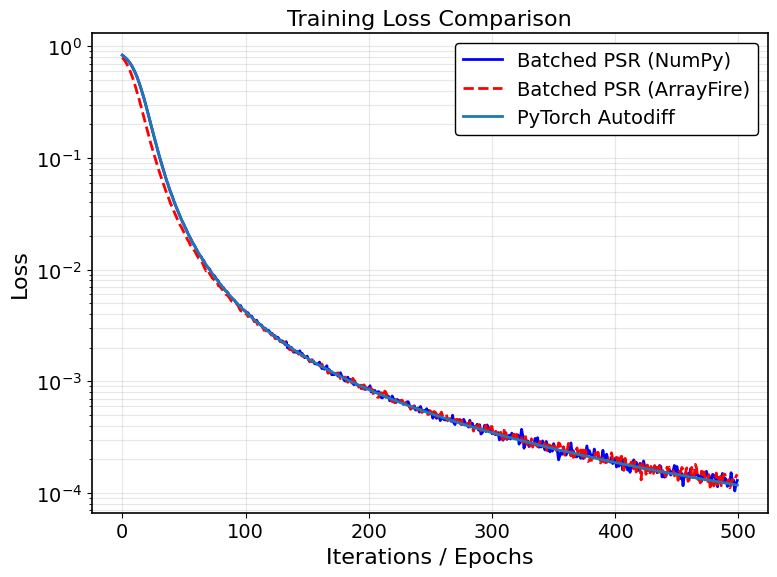

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. 设置你要求的大字体和线宽风格
mpl.rcParams.update({
    "font.size": 14,          # 基础字体
    "axes.labelsize": 16,     # x, y 轴标题
    "axes.titlesize": 16,     # 图表标题
    "xtick.labelsize": 14,    # x 轴刻度标签
    "ytick.labelsize": 14,    # y 轴刻度标签
    "legend.fontsize": 14,    # 图例字体
    "axes.linewidth": 1.2,    # 坐标轴线宽
})

# 创建画布，设置一个合适的比例
plt.figure(figsize=(8, 6))

# 2. 绘制三条 Loss 曲线
# 这里使用了不同的线型 (linestyle) 和较粗的线宽 (linewidth) 以增加区分度和可读性
plt.plot(loss_np, label="Batched PSR (NumPy)", color='blue', linewidth=2, linestyle='-')
plt.plot(loss_af, label="Batched PSR (ArrayFire)", color='red', linestyle='--', linewidth=2)
plt.plot(loss_th, label="PyTorch Autodiff", linewidth=2)

# 3. Y轴使用对数坐标
plt.yscale("log")

# 4. 设置坐标轴标签和标题（针对 Loss 比较进行了调整）
plt.xlabel("Iterations / Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

# 5. 设置网格、图例和布局
plt.grid(True, which="both", alpha=0.3)
plt.legend(
    loc="upper right",  # 如果曲线经常挡住左上角，可以改为 "upper right" 或 "best"
    framealpha=1.0,
    facecolor="white",
    edgecolor="black"
)

# 紧凑布局并显示
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import torch
import torch.optim as optim
import time
import os

# ==========================================
# Global Hyperparameters
# ==========================================
LR = 0.1
EPOCHS = 500
N_SAMPLES = 10000
X_TRAIN = np.linspace(-np.pi, np.pi, 20)
NUM_RUNS = 10 # 自动运行次数

# =====================================================================
# PART 1: BATCHED CUDA (COMPLEX PAULI) & STOCHASTIC PSR
# =====================================================================

# 自动检测 CUDA，如果不可用则回退到 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
f_dtype = torch.float32
c_dtype = torch.complex64 # 使用复数数据类型

# --- Standard 2x2 Complex Pauli Matrices ---
I_c = torch.tensor([[1, 0], [0, 1]], dtype=c_dtype, device=device)
X_c = torch.tensor([[0, 1], [1, 0]], dtype=c_dtype, device=device)
Y_c = torch.tensor([[0, -1j], [1j, 0]], dtype=c_dtype, device=device)
Z_c = torch.tensor([[1, 0], [0, -1]], dtype=c_dtype, device=device)

def rx_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * X_c

def ry_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * Y_c

def rz_batched(theta):
    theta = torch.atleast_1d(torch.as_tensor(theta, device=device, dtype=f_dtype)).view(-1, 1, 1)
    return torch.cos(theta/2) * I_c - 1j * torch.sin(theta/2) * Z_c

# 原生 Ansatz: 估算 f(x)
def q_ansatz_L1_batched(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    t0_t = torch.atleast_1d(torch.as_tensor(thetas[0], device=device, dtype=f_dtype))
    t1_t = torch.atleast_1d(torch.as_tensor(thetas[1], device=device, dtype=f_dtype))

    N = max(x_t.numel(), t0_t.numel(), t1_t.numel())

    # 初始态 |0>，维度 (N, 2, 1)
    state = torch.tensor([[1.+0.j], [0.+0.j]], dtype=c_dtype, device=device).expand(N, 2, 1)

    # 依次施加量子门
    state = ry_batched(x_t) @ state
    state = rz_batched(t1_t) @ state
    state = rx_batched(t0_t) @ state

    # 计算测量到 |0> 的概率：直接取第0个分量的复数模长平方
    prob_0 = state[:, 0, 0].abs() ** 2
    outcomes = torch.where(torch.rand(N, device=device) < prob_0, 1.0, -1.0)
    return outcomes

# Average Operator Ansatz: 估算 Af(x)
def q_ansatz_L1_batched_Af(x, thetas):
    x_t = torch.atleast_1d(torch.as_tensor(x, device=device, dtype=f_dtype))
    # 为 batch 中的每个样本生成随机符号：50% 是 1，50% 是 -1
    signs = torch.where(torch.rand(x_t.shape, device=device) < 0.5, 1.0, -1.0)
    x_flipped = x_t * signs
    # 将翻转后的 x 输入到原始的 ansatz 中
    return q_ansatz_L1_batched(x_flipped, thetas)

# --- PSR 梯度估算器 ---
def stochastic_psr_1st_x_gpu(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_plus = torch.full((num_samples,), float(x) + s, device=device, dtype=f_dtype)
    x_minus = torch.full((num_samples,), float(x) - s, device=device, dtype=f_dtype)
    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_2nd_x_gpu(x, thetas, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([2.0, -2.0], device=device)
    G_minus = torch.tensor([0.0, 0.0], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    x_plus = float(x) + G_plus[idx_plus] * s
    x_minus = float(x) + G_minus[idx_minus] * s

    A_plus_est = ansatz_func(x_plus, thetas).mean()
    A_minus_est = ansatz_func(x_minus, thetas).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def psr_1st_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    x_batch = torch.full((num_samples,), float(x), device=device, dtype=f_dtype)

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + s
    t_minus[target_idx] = float(thetas[target_idx]) - s

    f_plus_est = ansatz_func(x_batch, t_plus).mean()
    f_minus_est = ansatz_func(x_batch, t_minus).mean()
    return 0.5 * (f_plus_est - f_minus_est).item()

def stochastic_psr_2nd_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[1.0, 1.0], [-1.0, -1.0]], device=device)
    G_minus = torch.tensor([[-1.0, 1.0], [1.0, -1.0]], device=device)

    idx_plus = torch.randint(0, 2, (num_samples,), device=device)
    idx_minus = torch.randint(0, 2, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

def stochastic_psr_3rd_theta_gpu(x, thetas, target_idx, num_samples, ansatz_func=q_ansatz_L1_batched):
    s = np.pi / 2
    G_plus = torch.tensor([[2.0, 1.0], [-2.0, 1.0], [0.0, -1.0], [0.0, -1.0]], device=device)
    G_minus = torch.tensor([[2.0, -1.0], [-2.0, -1.0], [0.0, 1.0], [0.0, 1.0]], device=device)

    idx_plus = torch.randint(0, 4, (num_samples,), device=device)
    idx_minus = torch.randint(0, 4, (num_samples,), device=device)

    shifts_plus = G_plus[idx_plus] * s
    shifts_minus = G_minus[idx_minus] * s

    x_plus = float(x) + shifts_plus[:, 0]
    x_minus = float(x) + shifts_minus[:, 0]

    t_plus, t_minus = list(thetas), list(thetas)
    t_plus[target_idx] = float(thetas[target_idx]) + shifts_plus[:, 1]
    t_minus[target_idx] = float(thetas[target_idx]) + shifts_minus[:, 1]

    A_plus_est = ansatz_func(x_plus, t_plus).mean()
    A_minus_est = ansatz_func(x_minus, t_minus).mean()
    return 0.5 * (A_plus_est - A_minus_est).item()

# --- 训练循环 ---
def train_batched_psr(init_thetas):
    thetas = init_thetas.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)
            f_val = q_ansatz_L1_batched(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_gpu(x, thetas, N_SAMPLES)
            f_xx_val = stochastic_psr_2nd_x_gpu(x, thetas, N_SAMPLES)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_gpu(x, thetas, p_idx, N_SAMPLES)
                d_fx_theta = stochastic_psr_2nd_theta_gpu(x, thetas, p_idx, N_SAMPLES)
                d_fxx_theta = stochastic_psr_3rd_theta_gpu(x, thetas, p_idx, N_SAMPLES)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_history.append(total_loss / len(X_TRAIN))

    elapsed_time = time.time() - start_time
    return loss_history, thetas, elapsed_time

def train_batched_psr_Af(init_thetas):
    thetas = init_thetas.copy()
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        grad_thetas = np.zeros(2)
        total_loss = 0.0

        for x in X_TRAIN:
            x_batch = torch.full((N_SAMPLES,), float(x), device=device, dtype=f_dtype)

            f_val = q_ansatz_L1_batched_Af(x_batch, thetas).mean().item()
            f_x_val = stochastic_psr_1st_x_gpu(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
            f_xx_val = stochastic_psr_2nd_x_gpu(x, thetas, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

            res = f_xx_val + f_x_val + f_val - np.sin(x)
            total_loss += 0.5 * (res ** 2)

            for p_idx in range(2):
                d_f_theta = psr_1st_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fx_theta = stochastic_psr_2nd_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)
                d_fxx_theta = stochastic_psr_3rd_theta_gpu(x, thetas, p_idx, N_SAMPLES, ansatz_func=q_ansatz_L1_batched_Af)

                grad_res = d_fxx_theta + d_fx_theta + d_f_theta
                grad_thetas[p_idx] += res * grad_res

        thetas -= LR * (grad_thetas / len(X_TRAIN))
        loss_history.append(total_loss / len(X_TRAIN))

    elapsed_time = time.time() - start_time
    return loss_history, thetas, elapsed_time


# =====================================================================
# PART 2: PYTORCH & AUTOMATIC DIFFERENTIATION IMPLEMENTATION (CPU BASELINE)
# =====================================================================

I_th = torch.tensor([[1, 0], [0, 1]], dtype=torch.complex128)
X_th = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128)
Y_th = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128)
Z_th = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)

def rx_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * X_th

def ry_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Y_th

def rz_th(theta):
    return torch.cos(theta/2) * I_th - 1j * torch.sin(theta/2) * Z_th

def q_ansatz_L1_torch(x, thetas):
    state = torch.tensor([1, 0], dtype=torch.complex128)
    state = ry_th(x) @ state
    state = rx_th(thetas[0]) @ rz_th(thetas[1]) @ state
    exp_val = torch.vdot(state, Z_th @ state).real
    return exp_val

def train_pytorch_autodiff(init_thetas):
    thetas = torch.nn.Parameter(torch.tensor(init_thetas, dtype=torch.float64))
    optimizer = optim.SGD([thetas], lr=LR)
    loss_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        total_loss = 0.0

        for x_val in X_TRAIN:
            x = torch.tensor([x_val], dtype=torch.float64, requires_grad=True)

            f_val = q_ansatz_L1_torch(x, thetas)
            f_x_val = torch.autograd.grad(f_val, x, create_graph=True)[0]
            f_xx_val = torch.autograd.grad(f_x_val, x, create_graph=True)[0]

            res = f_xx_val + f_x_val + f_val - torch.sin(x)
            loss = 0.5 * (res ** 2)
            total_loss = total_loss + loss

        mean_loss = total_loss / len(X_TRAIN)
        mean_loss.backward()
        optimizer.step()
        loss_history.append(mean_loss.item())

    elapsed_time = time.time() - start_time
    return loss_history, thetas.detach().numpy(), elapsed_time


# =====================================================================
# PART 3: AUTOMATED EXECUTION & SAVING (NUMPY FORMAT)
# =====================================================================
if __name__ == "__main__":
    # 创建保存目录
    SAVE_DIR = "training_results_numpy"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # 用来收集所有轮次的最终核心结果，最后保存为一个总的汇总文件
    summary_data = []

    print(f"Starting {NUM_RUNS} automated runs...")
    print(f"Results will be saved as .npz files to the '{SAVE_DIR}' directory.\n")

    for run_id in range(1, NUM_RUNS + 1):
        # 设定随机种子以验证鲁棒性
        seed = run_id * 42
        np.random.seed(seed)
        torch.manual_seed(seed)

        # 每一轮随机生成一对初始参数（为了公平对比，三个模型在同一轮使用相同的初始参数）
        shared_init_thetas = np.random.uniform(0.1, 1.0, 2)

        print(f"--- RUN {run_id:02d}/{NUM_RUNS} | Seed: {seed:<3} | Init Thetas: [{shared_init_thetas[0]:.4f}, {shared_init_thetas[1]:.4f}] ---")

        # 运行三个模型
        loss_np, final_thetas_np, time_np = train_batched_psr(shared_init_thetas)
        loss_af, final_thetas_af, time_af = train_batched_psr_Af(shared_init_thetas)
        loss_th, final_thetas_th, time_th = train_pytorch_autodiff(shared_init_thetas)

        # 1. 使用 np.savez 保存当前轮次的所有详细数据到一个 .npz 文件中
        npz_path = os.path.join(SAVE_DIR, f"run_{run_id:02d}_data.npz")
        np.savez(
            npz_path,
            run_id=run_id,
            seed=seed,
            init_thetas=shared_init_thetas,

            # PSR_fx 数据
            psr_fx_final_thetas=final_thetas_np,
            psr_fx_final_loss=loss_np[-1],
            psr_fx_time=time_np,
            psr_fx_loss_history=np.array(loss_np),

            # PSR_Afx 数据
            psr_afx_final_thetas=final_thetas_af,
            psr_afx_final_loss=loss_af[-1],
            psr_afx_time=time_af,
            psr_afx_loss_history=np.array(loss_af),

            # Torch Autodiff 数据
            torch_final_thetas=final_thetas_th,
            torch_final_loss=loss_th[-1],
            torch_time=time_th,
            torch_loss_history=np.array(loss_th)
        )

        # 2. 记录核心汇总信息，结构为 16 列的行向量
        summary_data.append([
            run_id, seed, shared_init_thetas[0], shared_init_thetas[1],
            time_np, loss_np[-1], final_thetas_np[0], final_thetas_np[1],
            time_af, loss_af[-1], final_thetas_af[0], final_thetas_af[1],
            time_th, loss_th[-1], final_thetas_th[0], final_thetas_th[1]
        ])

        print(f"  > Run {run_id} complete. Data saved to {npz_path}")

    # 3. 将所有轮次的汇总数据保存为一个统一的 .npy 文件
    summary_path = os.path.join(SAVE_DIR, "all_runs_summary.npy")
    np.save(summary_path, np.array(summary_data))

    print(f"\nAll {NUM_RUNS} runs completed successfully!")
    print(f"Summary saved to: {summary_path}")

Starting 10 automated runs...
Results will be saved as .npz files to the 'training_results_numpy' directory.

--- RUN 06/10 | Seed: 252 | Init Thetas: [0.1049, 0.4899] ---
  > Run 6 complete. Data saved to training_results_numpy\run_06_data.npz
--- RUN 07/10 | Seed: 294 | Init Thetas: [0.7012, 0.2227] ---
  > Run 7 complete. Data saved to training_results_numpy\run_07_data.npz
--- RUN 08/10 | Seed: 336 | Init Thetas: [0.4964, 0.9069] ---
  > Run 8 complete. Data saved to training_results_numpy\run_08_data.npz
--- RUN 09/10 | Seed: 378 | Init Thetas: [0.6349, 0.1460] ---
  > Run 9 complete. Data saved to training_results_numpy\run_09_data.npz
--- RUN 10/10 | Seed: 420 | Init Thetas: [0.3841, 0.5077] ---
  > Run 10 complete. Data saved to training_results_numpy\run_10_data.npz

All 10 runs completed successfully!
Summary saved to: training_results_numpy\all_runs_summary.npy


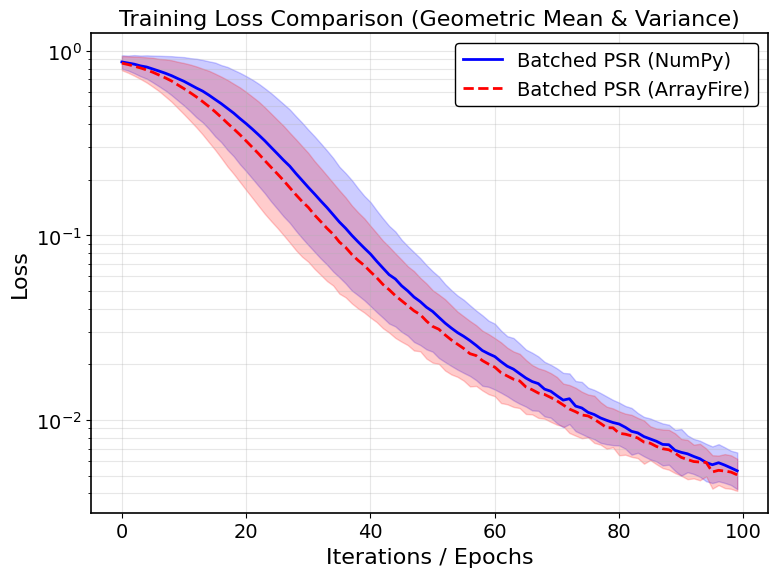

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. 读取数据并计算 Geometric Mean 和 Variance
# ==========================================
SAVE_DIR = "training_results_numpy"
NUM_RUNS = 10

loss_np_all = []
loss_af_all = []
loss_th_all = []

# 遍历加载10次运行的 npz 文件
for run_id in range(1, NUM_RUNS + 1):
    npz_path = os.path.join(SAVE_DIR, f"run_{run_id:02d}_data.npz")
    data = np.load(npz_path)
    loss_np_all.append(data['psr_fx_loss_history'])
    loss_af_all.append(data['psr_afx_loss_history'])
    loss_th_all.append(data['torch_loss_history'])

# 转换为 NumPy 数组，维度为 (10, EPOCHS)
loss_np_all = np.array(loss_np_all)
loss_af_all = np.array(loss_af_all)
loss_th_all = np.array(loss_th_all)

# --- 在 Log 空间下计算均值和标准差 (几何平均和几何方差) ---
eps = 1e-10  # 避免 log(0)
log_loss_np = np.log(loss_np_all + eps)
log_loss_af = np.log(loss_af_all + eps)
log_loss_th = np.log(loss_th_all + eps)

# 在对数域求 mean 和 std
log_mean_np = np.mean(log_loss_np, axis=0)
log_std_np = np.std(log_loss_np, axis=0)

log_mean_af = np.mean(log_loss_af, axis=0)
log_std_af = np.std(log_loss_af, axis=0)

log_mean_th = np.mean(log_loss_th, axis=0)
log_std_th = np.std(log_loss_th, axis=0)

# 转回到线性空间
# 几何平均值 (画主曲线用)
mean_np = np.exp(log_mean_np)
mean_af = np.exp(log_mean_af)
mean_th = np.exp(log_mean_th)

# 几何方差的上下界 (画阴影用)
upper_np = np.exp(log_mean_np + log_std_np)
lower_np = np.exp(log_mean_np - log_std_np)

upper_af = np.exp(log_mean_af + log_std_af)
lower_af = np.exp(log_mean_af - log_std_af)

upper_th = np.exp(log_mean_th + log_std_th)
lower_th = np.exp(log_mean_th - log_std_th)

# --- 截取前 100 个 epoch ---
N_PLOT = 100
epochs = np.arange(N_PLOT)

mean_np = mean_np[:N_PLOT]
mean_af = mean_af[:N_PLOT]
mean_th = mean_th[:N_PLOT]

upper_np = upper_np[:N_PLOT]
lower_np = lower_np[:N_PLOT]

upper_af = upper_af[:N_PLOT]
lower_af = lower_af[:N_PLOT]

upper_th = upper_th[:N_PLOT]
lower_th = lower_th[:N_PLOT]

# ==========================================
# 2. 按照指定风格绘图
# ==========================================
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.linewidth": 1.2,
})

plt.figure(figsize=(8, 6))

# 绘制平均值曲线
plt.plot(epochs, mean_np, label="Batched PSR (NumPy)", color='blue', linewidth=2, linestyle='-')
plt.plot(epochs, mean_af, label="Batched PSR (ArrayFire)", color='red', linestyle='--', linewidth=2)
# plt.plot(epochs, mean_th, label="PyTorch Autodiff", color='green', linestyle='-.', linewidth=2)

# 使用 fill_between 绘制 Geometric Variance (上下界阴影区域)
plt.fill_between(epochs, lower_np, upper_np, color='blue', alpha=0.2)
plt.fill_between(epochs, lower_af, upper_af, color='red', alpha=0.2)
# plt.fill_between(epochs, lower_th, upper_th, color='green', alpha=0.2)

# 设置Y轴对数坐标
plt.yscale("log")

# 设置坐标轴标签和标题
plt.xlabel("Iterations / Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Geometric Mean & Variance)")

# 设置网格、图例和布局
plt.grid(True, which="both", alpha=0.3)
plt.legend(
    loc="upper right",
    framealpha=1.0,
    facecolor="white",
    edgecolor="black"
)

plt.tight_layout()
plt.show()